<a href="https://colab.research.google.com/github/Danae-Munoz/Analisis_Data_Mineria-de-datos/blob/main/evaluacion_3_danae_munoz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Calificación y precio del vino - Evaluación de Minería de Datos**


## Información del Grupo

- **Nombre o Número de Grupo: 10**
- **Sección: 002D**
- **Fecha de Entrega:24/05/2026**


## Integrante del Grupo

- **Nombre: Danae**
- **Apellido: Muñoz Opitz**
- **Correo institucional: dana.munozo@duocuc.cl**

**URL:** https://www.kaggle.com/datasets/budnyak/wine-rating-and-price

---

# **1. Comprensión del Negocio**

## Tema del Proyecto
A partir del análisis del dataset obtenido desde Vivino.com, se observa una alta variabilidad en los precios de los vinos, junto con diferencias en características como la calificación (Rating), la cantidad de valoraciones (NumberOfRatings), el año de producción (Year), el país de origen (Country) y el tipo de vino (WineStyle).

Sin embargo, no siempre resulta evidente cómo estas variables influyen en el precio final del producto, especialmente considerando que vinos con características similares pueden presentar diferencias importantes de valor en el mercado.

En este contexto, surge la necesidad de comprender mejor los factores que determinan el precio de un vino, por lo que se propone el desarrollo de un modelo de aprendizaje automático capaz de predecir el precio en función de sus características disponibles.

Este enfoque permite identificar patrones dentro de los datos, estimar precios de manera más objetiva y apoyar la toma de decisiones en escenarios donde existe poca información o baja visibilidad del producto.


## Descripción del Proyecto
El proyecto tiene como propósito analizar el comportamiento del mercado vitivinícola utilizando información obtenida desde la plataforma Vivino.com, con el fin de identificar las variables que influyen en el precio de los vinos y desarrollar un modelo predictivo basado en machine learning.

Este modelo puede resultar útil para consumidores, distribuidores, tiendas especializadas o plataformas de venta de vinos, ya que permitiría estimar precios de forma automática considerando características como el país, el tipo de vino, el rating, el año y la popularidad del producto.

Además de la predicción, el análisis busca comprender las relaciones existentes entre las variables del dataset, detectar patrones de mercado y evaluar qué factores tienen mayor impacto en el valor final de un vino.



# **Importación de Librerias**

In [ ]:
# Importación de las librerías necesarias
# Librería para manipulación y análisis de datos en tablas (DataFrames)
import pandas as pd
# Librería para operaciones matemáticas y manejo de arreglos numéricos
import numpy as np
# Librería para crear gráficos básicos (histogramas, líneas, etc.)
import matplotlib.pyplot as plt
# Librería basada en matplotlib para visualizaciones estadísticas más avanzadas
import seaborn as sb
# Herramienta para estandarizar variables numéricas (media 0, desviación 1)
from sklearn.preprocessing import StandardScaler
# Técnica para convertir variables categóricas en variables numéricas binarias
from sklearn.preprocessing import OneHotEncoder

* Se utilizaron diversas librerías de Python para el desarrollo del proyecto, incluyendo herramientas para manipulación de datos (pandas), operaciones numéricas (numpy), visualización de datos (matplotlib y seaborn), y técnicas de preprocesamiento como la estandarización de variables (StandardScaler) y la codificación de variables categóricas (OneHotEncoder).



# **Carga, integración y preparación del dataset**

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Ruta del archivo en Google Drive
ruta = '/content/drive/MyDrive/mineriadf/df_final.csv'


In [ ]:
# Cargar dataframe
df_final = pd.read_csv(ruta)
df_final.head()



,Rating,NumberOfRatings,Price,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,...,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white
0,4.2,100,95.00,2011,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4.3,100,15.50,2017,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.9,100,7.45,2015,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3.5,100,8.72,2019,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3.9,100,29.15,2016,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
# Devuelve la cantidad de filas y columnas respectivamente
df_final.shape

(13834, 41)

* Estos métodos permiten visualizar la estructura del DataFrame, identificando que el dataset cuenta con 13.834 filas y 9 columnas, sin presencia de valores nulos. Además, se observa una combinación de variables numéricas y categóricas, lo que requerirá un preprocesamiento posterior.

In [ ]:
# Visualizamos las primeras 5 filas del DataFrame
df_final.head()

,Rating,NumberOfRatings,Price,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,...,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white
0,4.2,100,95.00,2011,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4.3,100,15.50,2017,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.9,100,7.45,2015,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3.5,100,8.72,2019,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3.9,100,29.15,2016,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


* Se muestran las primeras cinco filas del dataset, donde es posible observar las distintas variables disponibles.

In [ ]:
# Visualizamos las ultimas 5 filas del DataFrame
df_final.tail()

,Rating,NumberOfRatings,Price,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,...,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white
13829,3.9,1750,9.36,2019,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13830,4.0,2046,12.85,2019,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13831,4.2,2990,16.47,2019,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13832,3.5,9493,4.35,2016,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
13833,3.6,29531,5.99,2016,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


* Se visualizaron las últimas cinco filas del dataset.

In [ ]:
# Observamos la columna y sus tipos de datos
df_final.dtypes

,0
Rating,float64
NumberOfRatings,int64
Price,float64
Year,int64
Country_Argentina,float64
Country_Australia,float64
Country_Austria,float64
Country_Brazil,float64
Country_Bulgaria,float64
Country_Canada,float64


* Mediante el uso del método dtypes, se pudo observar el tipo de dato de cada una de las variables presentes en el dataset.

# **Mapeo de datos**
* Country: Categórico Nominal
* Rating (Calificación promedio): Numérico Continuo
* NumberOfRatings (Número de personas que calificaron este vino): Numérico Discreto
* Price (Precio en EUR): Numérico Continuo
* Year(Año de producción): Numérico Discreto
* WineStyle: Categórico Nominal



**Clasificación de Variables**

* **Categórico Nominal:** Categorías sin un orden o jerarquía específica.
  * Ejemplo: Country, WineStyle.

* **Categórico Ordinal:** Categorías que siguen un orden lógico o escala.
  * Ejemplo: (En este dataset no se identifican variables ordinales explícitas)

* **Numérico Discreto:** Valores que surgen de un conteo y no admiten decimales.
  * Ejemplo: NumberOfRatings, Year.

* **Numérico Continuo:** Valores que resultan de una medición y pueden tener decimales infinitos.
  * Ejemplo: Price, Rating.


---



# **6. Entrenamiento y Evaluación**

In [ ]:
# Importamos librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos el modelo de Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor


#**Modelado 1:** Regresión Lineal

In [ ]:
# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo de Regresión Lineal
lr = LinearRegression()

# Entrenamos el modelo
lr.fit(X_train, y_train)

# Predicción en escala logarítmica
y_pred_log = lr.predict(X_test)

# Volvemos las predicciones a escala original de precio
y_pred = np.expm1(y_pred_log)

# Volvemos y_test también a escala original
y_test_original = np.expm1(y_test)

# Evitamos precios negativos
y_pred = np.maximum(y_pred, 0)

* Se aplicó un modelo de Regresión Lineal para predecir el precio del vino utilizando como variables independientes las características disponibles del dataset. La variable objetivo (Price) fue transformada mediante log1p para reducir el efecto de precios extremos y mejorar el ajuste del modelo. Luego, el dataset se dividió en un 70% para entrenamiento y un 30% para prueba. Posteriormente, las predicciones fueron devueltas a su escala original en euros mediante expm1, permitiendo comparar el precio real con el precio estimado.

In [ ]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 15.294587527745708
MSE: 3167.8134729698545
RMSE: 56.28333210613827
R2: 0.3928450160734641


* El modelo de Regresión Lineal obtuvo un MAE de aproximadamente 15,29€, lo que indica que las predicciones presentan un error promedio cercano a ese valor respecto al precio real. El RMSE fue de 56,28€, evidenciando la existencia de errores más grandes asociados principalmente a vinos con precios extremos. Por otro lado, el R² obtenido fue de 0,39, lo que significa que el modelo logra explicar cerca del 39% de la variabilidad del precio de los vinos. En general, el modelo presenta un desempeño moderado y puede utilizarse como una aproximación inicial para la predicción de precios.

#**Modelado 2:** Árboles de Decisión

In [ ]:
# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo
tree = DecisionTreeRegressor(
    max_depth=10,
    random_state=100
)

# Entrenamos el modelo
tree.fit(X_train, y_train)

# Predicciones
y_pred_log = tree.predict(X_test)

# Volvemos a escala normal
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evitamos negativos
y_pred = np.maximum(y_pred, 0)

* Se implementó un modelo de Árbol de Decisión para regresión con el objetivo de predecir el precio de los vinos. El modelo fue entrenado utilizando las variables procesadas del dataset y la variable objetivo transformada mediante log1p para reducir el impacto de valores extremos. Posteriormente, las predicciones fueron transformadas nuevamente a su escala original en euros utilizando expm1.

In [ ]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2 )

MAE: 16.39643038507426
MSE: 7067.3675785157275
RMSE: 84.06763692715364
R2: -0.3545581156057769


* El modelo Árbol de Decisión para regresión presentó el desempeño más bajo entre los modelos evaluados. Obtuvo un MAE de 16,39, lo que indica que, en promedio, sus predicciones se alejan aproximadamente 16,39 € del precio real. Además, obtuvo un R² negativo de -0,3545, lo que significa que el modelo no logró explicar correctamente la variabilidad del precio del vino. Este resultado indica que el Árbol de Decisión no generalizó bien los datos y tuvo dificultades para realizar predicciones precisas en este caso.

#**Modelado 3:** Random Forest Regressor


In [ ]:
# Importamos Random Forest
from sklearn.ensemble import RandomForestRegressor

# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=100,
    n_jobs=-1
)

# Entrenamos el modelo
rf.fit(X_train, y_train)

# Predicciones
y_pred_log = rf.predict(X_test)

# Volvemos a escala original
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evitamos negativos
y_pred = np.maximum(y_pred, 0)

* Se implementó un modelo Random Forest Regressor utilizando múltiples árboles de decisión para predecir el precio de los vinos. La variable objetivo fue transformada mediante log1p para reducir el impacto de valores extremos y mejorar el rendimiento del modelo.

* Posteriormente, las predicciones fueron transformadas nuevamente a su escala original utilizando expm1, permitiendo interpretar los resultados en euros.

In [ ]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 13.943249829113883
MSE: 2411.181137332057
RMSE: 49.103779257120905
R2: 0.5378640007776926


* El modelo Random Forest Regressor presentó el mejor desempeño entre los tres modelos evaluados. Obtuvo un MAE de 13,94, lo que indica que, en promedio, sus predicciones se desvían aproximadamente 13,94 € del precio real. Además, alcanzó un R² de 0,5376, por lo que logra explicar cerca del 53,76% de la variabilidad del precio del vino. Esto demuestra que el modelo tiene una mejor capacidad predictiva, ya que combina múltiples árboles de decisión y logra capturar relaciones más complejas entre las variables.

In [ ]:
# Comparamos precios reales y predichos
comparacion = pd.DataFrame({
    'Precio real': y_test_original,
    'Precio predicho': y_pred
})

comparacion.head(10)

,Precio real,Precio predicho
1206,25.02,10.675939
6016,25.12,12.921368
3867,11.19,7.560024
11382,27.50,29.220178
3603,8.40,9.478488
379,39.90,45.484094
11757,7.36,16.232060
7679,57.72,35.164924
9818,9.99,8.825704
5638,131.60,51.973509


* La tabla compara los precios reales con los precios predichos por el modelo Random Forest Regressor. Se observa que el modelo logra acercarse correctamente en algunos casos, como en el vino de 27,50 €, donde predice 29,22 €, y en el vino de 39,90 €, donde predice 45,48 €. Sin embargo, presenta diferencias importantes en valores más altos, como el caso del vino de 131,60 €, donde predice 51,97 €. Esto indica que el modelo tiene un mejor comportamiento general que los anteriores, pero aún presenta dificultades para estimar precios extremos o atípicos.

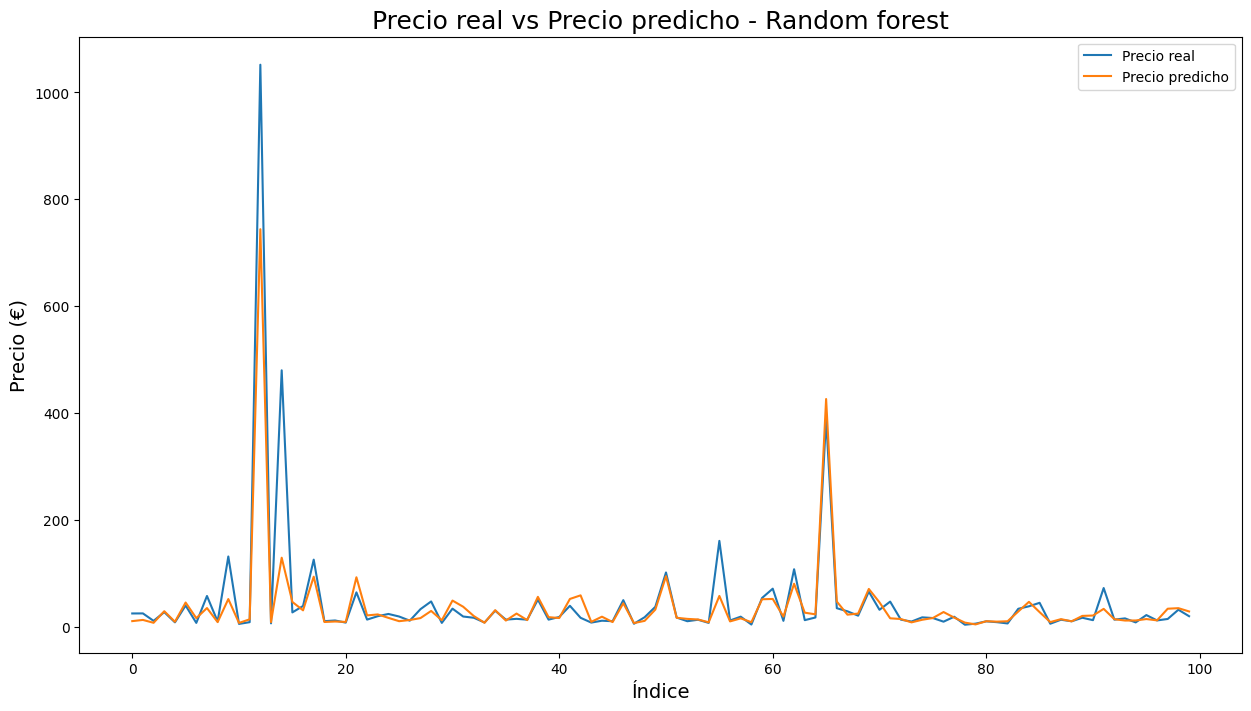

In [ ]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Cantidad de registros que se mostrarán en el gráfico
cantidad = 100

# Graficamos los precios reales
plt.plot(
    range(cantidad),
    y_test_original.iloc[:cantidad],
    label="Precio real"
)

# Graficamos los precios predichos por el modelo
plt.plot(
    range(cantidad),
    y_pred[:cantidad],
    label="Precio predicho"
)

# Agregamos título y nombres a los ejes
plt.title("Precio real vs Precio predicho - Random forest", fontsize=18)
plt.xlabel("Índice", fontsize=14)
plt.ylabel("Precio (€)", fontsize=14)

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico final
plt.show()

* El gráfico compara los precios reales con los precios predichos por el modelo Random Forest Regressor. Se observa que, en la mayoría de los registros, la línea del precio predicho sigue una tendencia similar a la del precio real, especialmente en valores bajos y medios. Esto indica que el modelo logra aproximarse de mejor manera al comportamiento general de los datos.

* Sin embargo, también se evidencian diferencias en algunos valores extremos. Por ejemplo, cuando existen precios reales muy altos, el modelo tiende a subestimarlos, aunque logra acercarse más que los modelos anteriores. En general, el Random Forest presenta un mejor ajuste y una mayor estabilidad predictiva, pero aún mantiene dificultades para predecir correctamente vinos con precios atípicamente elevados.


---



#**7. Dashboard para toma de decisiones**

In [ ]:
# Exportamos el dataset limpio para utilizarlo en Power BI o Looker Studio
df_final.to_csv("dataset_vinos_dashboard.csv", index=False)

print("Archivo dataset_vinos_dashboard.csv generado correctamente.")

Archivo dataset_vinos_dashboard.csv generado correctamente.


* Se exportó el dataset limpio en formato CSV para ser utilizado en una herramienta de visualización como Power BI o Looker Studio. Este archivo permite construir un panel interactivo orientado al análisis del precio, rating, país, año y estilo de los vinos.

El dashboard desarrollado en Looker Studio incluye los siguientes indicadores y gráficos:

- Total de vinos analizados.
- Precio promedio de los vinos.
- Rating promedio de los vinos.
- Cantidad total de valoraciones.
- Top 10 países con mayor cantidad de vinos.
- Cantidad de vinos por estilo.
- Precio promedio por década.
- Top 10 países con vinos más caros.

In [ ]:
# Importamos las funciones necesarias para mostrar contenido dentro del notebook
from IPython.display import display, Markdown

# Guardamos en una variable el enlace del dashboard creado en Looker Studio
link_looker = "https://datastudio.google.com/reporting/65319531-a005-4a18-8979-30f59ee15cb8"

# Mostramos el enlace del dashboard en formato Markdown para que sea clickeable desde Colab
display(Markdown(f"[Abrir Dashboard en Looker Studio]({link_looker})"))

[Abrir Dashboard en Looker Studio](https://datastudio.google.com/reporting/65319531-a005-4a18-8979-30f59ee15cb8)

* Se incorporó el enlace al dashboard desarrollado en Looker Studio, el cual utiliza el archivo dataset_vinos_dashboard.csv como fuente de datos. Este panel permite visualizar los resultados del análisis realizado en Colab y apoyar la toma de decisiones mediante gráficos interactivos.

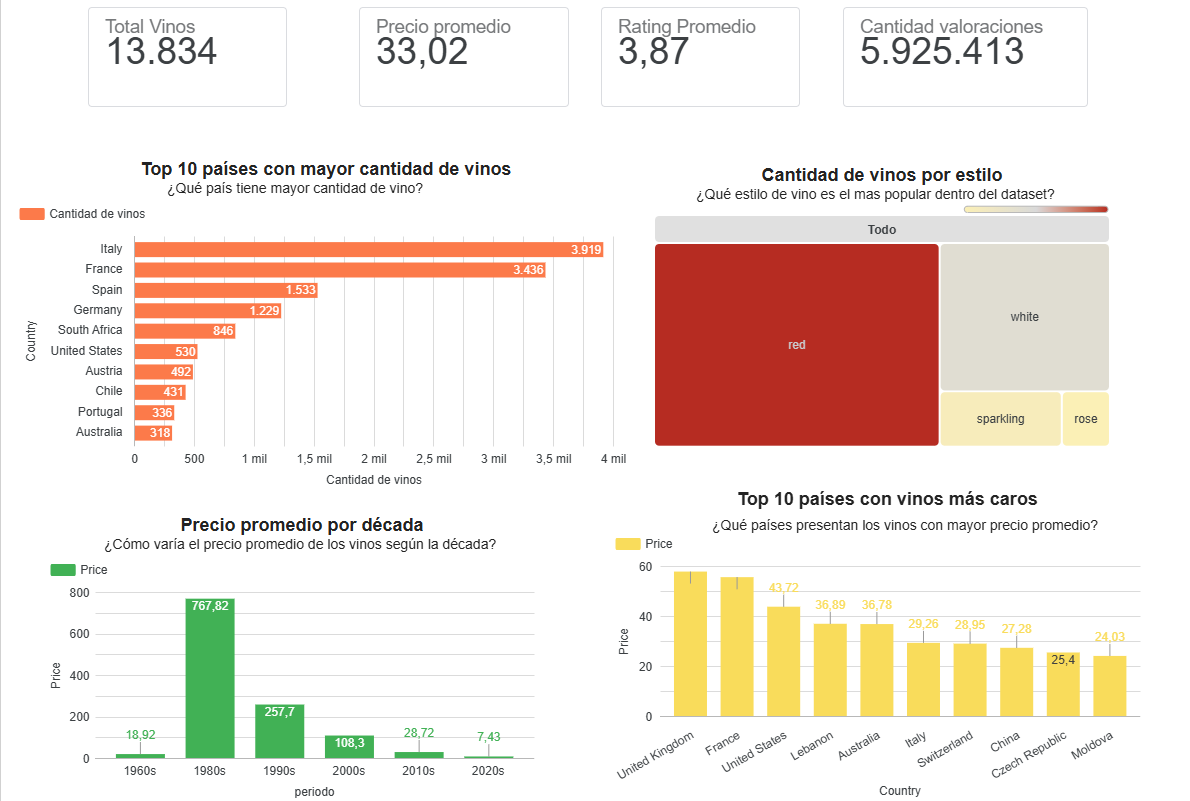

# **8. Web Scraping VIVINO para aumentar/testear el modelo con datos reales**

En esta etapa se realiza un proceso de web scraping desde Vivino, plataforma relacionada directamente con el dataset original utilizado en el proyecto. El objetivo es recolectar productos reales desde la página web, preparar sus variables y utilizarlas para testear el modelo predictivo con datos externos.

El proceso consiste en ingresar a Vivino, recolectar automáticamente enlaces de productos, acceder a cada página de vino y extraer información como nombre, rating, cantidad de valoraciones, año, país, estilo de vino y precio publicado cuando esté disponible.

Posteriormente, los datos recolectados son transformados para mantener compatibilidad con la estructura utilizada durante el entrenamiento del modelo de Machine Learning.

https://www.vivino.com/es/

In [ ]:
# Importamos librerías necesarias para realizar web scraping y procesamiento de datos
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
from urllib.parse import urljoin

In [ ]:
# Recolección automática de enlaces de vinos desde Vivino
# URL base de Vivino
url_base_vivino = "https://www.vivino.com/es/"

# Encabezados para simular una solicitud desde navegador
headers_vivino = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "es-CL,es;q=0.9,en;q=0.8",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Referer": "https://www.vivino.com/es/"
}

# Solicitamos la página principal de Vivino
response = requests.get(url_base_vivino, headers=headers_vivino, timeout=20)

# Mostramos el estado de la solicitud
print("Estado de la solicitud:", response.status_code)

# Procesamos el HTML obtenido
soup = BeautifulSoup(response.text, "html.parser")

# Lista para guardar enlaces de productos encontrados
links_vivino = []

# Recorremos todos los enlaces disponibles en la página
for link in soup.find_all("a", href=True):
    href = link["href"]

    # En Vivino, las páginas de vinos suelen contener la ruta /w/
    if "/w/" in href:
        url_producto = urljoin("https://www.vivino.com", href)
        links_vivino.append(url_producto)

# Eliminamos enlaces duplicados
links_vivino = list(set(links_vivino))

# Mostramos la cantidad de enlaces encontrados
print("Cantidad de enlaces de vinos encontrados:", len(links_vivino))

# Visualizamos algunos enlaces encontrados
links_vivino[:10]

Estado de la solicitud: 200
Cantidad de enlaces de vinos encontrados: 54


['https://www.vivino.com/en/san-marzano-sixty-sessantanni-old-vines-primitivo-di-manduria/w/11890?year=2019&price_id=38162783',
 'https://www.vivino.com/en/salvano-barbaresco/w/1209113?year=2019&price_id=42724773',
 'https://www.vivino.com/en/campagnola-cantico-asti/w/73187?price_id=35496536',
 'https://www.vivino.com/en/tinazzi-tenuta-valleselle-rovertondo-valpolicella-ripasso-superiore/w/1125483?year=2019&price_id=32422375',
 'https://www.vivino.com/en/monte-faustino-amarone-della-valpolicella-classico/w/1176903?year=2019&price_id=39792414',
 'https://www.vivino.com/en/cervoles-vinyes-altes-de-les-garrigues-vi-blanc-costers-del-segre/w/5463577?year=2019&price_id=38289499',
 'https://www.vivino.com/en/saracosa-toscana-governo-rosso-tuscany/w/5292597?year=2021&price_id=38378544',
 'https://www.vivino.com/en/varvaglione-papale-primitivo-di-manduria-primitivo-di-manduria/w/1506422?year=2023&price_id=42280111',
 'https://www.vivino.com/en/felix-solis-mucho-mas-tinto/w/6266660?price_id=349

* Se realizó una solicitud a la página principal de Vivino y se procesó su contenido HTML. A partir de este contenido, se identificaron enlaces que contienen la ruta /w/, la cual corresponde a páginas de productos de vino dentro de Vivino. Estos enlaces serán utilizados para ingresar a cada producto y extraer información específica.

#**Funciones auxiliares para extracción y transformación**

In [ ]:
# Tipo de cambio referencial USD a EUR
# Se utiliza porque Vivino puede entregar precios en USD dentro del HTML
tipo_cambio_usd_a_eur = 0.93

# Tipo de cambio referencial CLP a EUR
# Se mantiene por si alguna página entrega precio en pesos chilenos
tipo_cambio_clp_por_eur = 1050


# Función para extraer el primer patrón encontrado mediante expresiones regulares
def extraer_regex(patron, texto, grupo=1):
    coincidencia = re.search(patron, texto, re.IGNORECASE)

    if coincidencia:
        return coincidencia.group(grupo)

    return np.nan


# Función para limpiar valores numéricos desde texto
def limpiar_numero(texto):
    if texto is None or pd.isna(texto):
        return np.nan

    texto = str(texto).replace(",", ".")
    coincidencia = re.search(r"\d+(\.\d+)?", texto)

    if coincidencia:
        return float(coincidencia.group(0))

    return np.nan


# Función para extraer año desde texto o URL
def extraer_anio(texto):
    coincidencia = re.search(r"\b(19[0-9]{2}|20[0-9]{2})\b", str(texto))

    if coincidencia:
        return int(coincidencia.group(0))

    return np.nan


# Función para convertir precio en USD a EUR
def convertir_usd_a_eur(precio_usd):
    if precio_usd is None or pd.isna(precio_usd):
        return np.nan

    return round(float(precio_usd) * tipo_cambio_usd_a_eur, 2)


# Función para convertir precio en CLP a EUR
def convertir_clp_a_eur(precio_clp):
    if precio_clp is None or pd.isna(precio_clp):
        return np.nan

    return round(float(precio_clp) / tipo_cambio_clp_por_eur, 2)


# Función para clasificar el estilo del vino según texto disponible
def clasificar_wine_style(texto):
    texto = str(texto).lower()

    if "sparkling" in texto or "espumoso" in texto or "espumante" in texto or "champagne" in texto:
        return "Sparkling"
    elif "rosé" in texto or "rose" in texto or "rosado" in texto:
        return "Rose"
    elif "white" in texto or "blanco" in texto or "riesling" in texto or "chardonnay" in texto or "sauvignon blanc" in texto:
        return "White"
    elif "red" in texto or "tinto" in texto or "cabernet" in texto or "merlot" in texto or "carmenere" in texto or "syrah" in texto:
        return "Red"
    else:
        return "Red"


# Función para clasificar el estilo según el código wine_type de Vivino
def clasificar_wine_type_id(wine_type_id):
    mapa_tipos = {
        "1": "Red",
        "2": "White",
        "3": "Sparkling",
        "4": "Rose"
    }

    return mapa_tipos.get(str(wine_type_id), np.nan)


# Función para estimar país desde el texto disponible
def estimar_pais(texto):
    texto = str(texto).lower()

    if "chile" in texto:
        return "Chile"
    elif "argentina" in texto:
        return "Argentina"
    elif "france" in texto or "francia" in texto:
        return "France"
    elif "spain" in texto or "españa" in texto:
        return "Spain"
    elif "italy" in texto or "italia" in texto:
        return "Italy"
    elif "germany" in texto or "alemania" in texto:
        return "Germany"
    elif "portugal" in texto:
        return "Portugal"
    elif "australia" in texto:
        return "Australia"
    elif "united states" in texto or "estados unidos" in texto:
        return "United States"
    else:
        return np.nan

* Se definieron funciones auxiliares para extraer y transformar los datos recolectados desde Vivino. Estas funciones permiten limpiar números, extraer años, convertir precios a euros, clasificar el estilo del vino y estimar el país cuando la información se encuentra disponible en el HTML.

#**Extracción de datos desde cada producto Vivino**




In [ ]:
# Lista para almacenar los productos recolectados desde Vivino
productos_vivino = []

# Cantidad máxima de productos a procesar para evitar saturar el sitio
max_productos = 50

# Recorremos los enlaces encontrados
for url_producto in links_vivino[:max_productos]:

    try:
        # Solicitamos la página de cada producto
        response_producto = requests.get(url_producto, headers=headers_vivino, timeout=20)

        # Mostramos estado de cada solicitud
        print("URL:", url_producto)
        print("Estado:", response_producto.status_code)

        # Si la página no responde correctamente, se omite
        if response_producto.status_code != 200:
            print("-" * 50)
            continue

        # Guardamos el HTML como texto
        html = response_producto.text

        # Procesamos el HTML con BeautifulSoup
        soup_producto = BeautifulSoup(html, "html.parser")

        # Extraemos título de la página
        titulo = soup_producto.title.get_text(strip=True) if soup_producto.title else np.nan

        # Extraemos descripción meta
        meta_desc = soup_producto.find("meta", attrs={"name": "description"})
        descripcion = meta_desc.get("content") if meta_desc else ""

        # Limpiamos el nombre del producto desde el título
        nombre_producto = str(titulo).replace("| Vivino Español", "").replace("| Vivino", "").strip()

        # Extraemos año desde la URL, título o descripción
        year = extraer_anio(url_producto)

        if pd.isna(year):
            year = extraer_anio(nombre_producto)

        if pd.isna(year):
            year = extraer_anio(descripcion)

        # Extraemos vintage_id desde el HTML si aparece
        vintage_id = extraer_regex(r'"vintage_id":\s*(\d+)', html)

        # Extraemos wine_style_id desde el HTML si aparece
        wine_style_id = extraer_regex(r'"wine_style_id":\s*(\d+)', html)

        # Extraemos wine_type desde scripts de publicidad si aparece
        wine_type_id = extraer_regex(r'setTargeting\("wine_type",\s*"(\d+)"\)', html)

        # Extraemos rating promedio
        rating = extraer_regex(r'"ratings_average":\s*([\d\.]+)', html)

        if pd.isna(rating):
            rating = extraer_regex(r'"average_rating":\s*([\d\.]+)', html)

        rating = limpiar_numero(rating)

        # Extraemos cantidad de valoraciones
        number_of_ratings = extraer_regex(r'"ratings_count":\s*(\d+)', html)

        if pd.isna(number_of_ratings):
            number_of_ratings = extraer_regex(r'"reviews_count":\s*(\d+)', html)

        number_of_ratings = limpiar_numero(number_of_ratings)

        # Extraemos precio default en USD si aparece
        precio_usd = extraer_regex(r'setTargeting\("default_price_usd",\s*"([\d\.]+)"\)', html)
        precio_usd = limpiar_numero(precio_usd)

        # Extraemos posible precio CLP si aparece dentro del HTML
        precio_clp = extraer_regex(r'"amount":\s*(\d+).*?"currency":\s*\{"code":"CLP"', html)
        precio_clp = limpiar_numero(precio_clp)

        # Convertimos precio a EUR
        if not pd.isna(precio_usd):
            precio_publicado_eur = convertir_usd_a_eur(precio_usd)
        elif not pd.isna(precio_clp):
            precio_publicado_eur = convertir_clp_a_eur(precio_clp)
        else:
            precio_publicado_eur = np.nan

        # Estimamos país desde texto disponible
        texto_base = nombre_producto + " " + descripcion + " " + html[:8000]
        country = estimar_pais(texto_base)

        # Clasificamos estilo del vino
        wine_style = clasificar_wine_type_id(wine_type_id)

        if pd.isna(wine_style):
            wine_style = clasificar_wine_style(texto_base)

        # Guardamos producto recolectado
        productos_vivino.append({
            "Nombre_producto": nombre_producto,
            "Vintage_ID": vintage_id,
            "Wine_Style_ID": wine_style_id,
            "Wine_Type_ID": wine_type_id,
            "Rating": rating,
            "NumberOfRatings": number_of_ratings,
            "Year": year,
            "Country": country,
            "WineStyle": wine_style,
            "Precio_publicado_USD": precio_usd,
            "Precio_publicado_CLP": precio_clp,
            "Precio_publicado_EUR": precio_publicado_eur,
            "Descripcion": descripcion,
            "URL_producto": url_producto
        })

        print("Producto recolectado:", nombre_producto)
        print("-" * 50)

        # Pausa breve para no saturar Vivino
        time.sleep(1)

    except Exception as e:
        print("Error al procesar:", url_producto)
        print("Detalle:", e)
        print("-" * 50)

# Creamos DataFrame con los productos recolectados
df_vivino = pd.DataFrame(productos_vivino)

# Eliminamos duplicados
if not df_vivino.empty:
    df_vivino = df_vivino.drop_duplicates(subset=["Nombre_producto", "URL_producto"])

# Mostramos cantidad total recolectada
print("Total de productos recolectados desde Vivino:", len(df_vivino))

# Visualizamos los primeros registros
df_vivino.head(10)

URL: https://www.vivino.com/en/san-marzano-sixty-sessantanni-old-vines-primitivo-di-manduria/w/11890?year=2019&price_id=38162783
Estado: 200
Producto recolectado: 2019 San Marzano 60 Sessantanni Old Vines Primitivo di Manduria  English
--------------------------------------------------
URL: https://www.vivino.com/en/salvano-barbaresco/w/1209113?year=2019&price_id=42724773
Estado: 200
Producto recolectado: 2019 Salvano Barbaresco
--------------------------------------------------
URL: https://www.vivino.com/en/campagnola-cantico-asti/w/73187?price_id=35496536
Estado: 200
Producto recolectado: N.V. Campagnola Cantico Asti
--------------------------------------------------
URL: https://www.vivino.com/en/tinazzi-tenuta-valleselle-rovertondo-valpolicella-ripasso-superiore/w/1125483?year=2019&price_id=32422375
Estado: 200
Producto recolectado: 2019 Tinazzi Tenuta Valleselle Rovertondo Valpolicella Ripasso Superiore
--------------------------------------------------
URL: https://www.vivino.co

,Nombre_producto,Vintage_ID,Wine_Style_ID,Wine_Type_ID,Rating,NumberOfRatings,Year,Country,WineStyle,Precio_publicado_USD,Precio_publicado_CLP,Precio_publicado_EUR,Descripcion,URL_producto
0,2019 San Marzano 60 Sessantanni Old Vines Prim...,159345173,248,1,4.3,4470.0,2019.0,NaN,Red,46.62,NaN,43.36,San Marzano 60 Sessantanni Old Vines Primitivo...,https://www.vivino.com/en/san-marzano-sixty-se...
1,2019 Salvano Barbaresco,164239218,5,1,4.2,36.0,2019.0,NaN,Red,41.33,NaN,38.44,Salvano Barbaresco es un Vino tinto. Hecho con...,https://www.vivino.com/en/salvano-barbaresco/w...
2,N.V. Campagnola Cantico Asti,1666055,4,3,4.4,56.0,NaN,NaN,Sparkling,28.43,NaN,26.44,Campagnola Cantico Asti es un Vino espumoso. H...,https://www.vivino.com/en/campagnola-cantico-a...
3,2019 Tinazzi Tenuta Valleselle Rovertondo Valp...,161331083,192,1,4.2,2192.0,2019.0,NaN,Red,42.45,NaN,39.48,Tinazzi Tenuta Valleselle Rovertondo Valpolice...,https://www.vivino.com/en/tinazzi-tenuta-valle...
4,2019 Monte Faustino Amarone della Valpolicella...,162718856,3,1,4.4,30.0,2019.0,NaN,Red,65.51,NaN,60.92,Monte Faustino Amarone della Valpolicella Clas...,https://www.vivino.com/en/monte-faustino-amaro...
5,2019 Cérvoles Vinyes Altes de Les Garrigues Vi...,166136896,810,2,4.2,120.0,2019.0,NaN,White,42.49,NaN,39.52,Cérvoles Vinyes Altes de Les Garrigues Vi Blan...,https://www.vivino.com/en/cervoles-vinyes-alte...
6,2021 Saracosa Toscana Governo Rosso English,167696953,292,1,4.2,313.0,2021.0,NaN,Red,33.37,NaN,31.03,Saracosa Toscana Governo Rosso is a Red wine. ...,https://www.vivino.com/en/saracosa-toscana-gov...
7,2023 Varvaglione Papale Primitivo di Manduria,173645641,248,1,4.0,138.0,2023.0,NaN,Red,23.18,NaN,21.56,Varvaglione Papale Primitivo di Manduria es un...,https://www.vivino.com/en/varvaglione-papale-p...
8,N.V. Félix Solís Mucho Más Tinto English,156848268,176,1,4.1,116052.0,NaN,NaN,Red,23.10,NaN,21.48,Félix Solís Mucho Más Tinto is a Red wine. Mad...,https://www.vivino.com/en/felix-solis-mucho-ma...


* Se ingresó a cada enlace de producto recolectado desde Vivino y se extrajo información disponible en el HTML. Entre las variables obtenidas se encuentran nombre del producto, rating, cantidad de valoraciones, año, país, estilo de vino y precio publicado. Los precios fueron convertidos a euros para mantener compatibilidad con la escala utilizada en el dataset original.

#**Validación de los datos recolectados desde Vivino**

In [ ]:
#Revisamos la cantidad de productos recolectados
print("Cantidad de productos recolectados:", len(df_vivino))

#Revisamos la estructura del DataFrame
df_vivino.info()

#Visualizamos las columnas principales
df_vivino[[
   "Nombre_producto",
   "Rating",
   "NumberOfRatings",
   "Year",
   "Country",
   "WineStyle",
   "Precio_publicado_USD",
   "Precio_publicado_CLP",
   "Precio_publicado_EUR"
]].head(10)

Cantidad de productos recolectados: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Nombre_producto       9 non-null      object 
 1   Vintage_ID            9 non-null      object 
 2   Wine_Style_ID         9 non-null      object 
 3   Wine_Type_ID          9 non-null      object 
 4   Rating                9 non-null      float64
 5   NumberOfRatings       9 non-null      float64
 6   Year                  7 non-null      float64
 7   Country               0 non-null      float64
 8   WineStyle             9 non-null      object 
 9   Precio_publicado_USD  9 non-null      float64
 10  Precio_publicado_CLP  0 non-null      float64
 11  Precio_publicado_EUR  9 non-null      float64
 12  Descripcion           9 non-null      object 
 13  URL_producto          9 non-null      object 
dtypes: float64(7), object(7)
memory usage: 1

,Nombre_producto,Rating,NumberOfRatings,Year,Country,WineStyle,Precio_publicado_USD,Precio_publicado_CLP,Precio_publicado_EUR
0,2019 San Marzano 60 Sessantanni Old Vines Prim...,4.3,4470.0,2019.0,NaN,Red,46.62,NaN,43.36
1,2019 Salvano Barbaresco,4.2,36.0,2019.0,NaN,Red,41.33,NaN,38.44
2,N.V. Campagnola Cantico Asti,4.4,56.0,NaN,NaN,Sparkling,28.43,NaN,26.44
3,2019 Tinazzi Tenuta Valleselle Rovertondo Valp...,4.2,2192.0,2019.0,NaN,Red,42.45,NaN,39.48
4,2019 Monte Faustino Amarone della Valpolicella...,4.4,30.0,2019.0,NaN,Red,65.51,NaN,60.92
5,2019 Cérvoles Vinyes Altes de Les Garrigues Vi...,4.2,120.0,2019.0,NaN,White,42.49,NaN,39.52
6,2021 Saracosa Toscana Governo Rosso English,4.2,313.0,2021.0,NaN,Red,33.37,NaN,31.03
7,2023 Varvaglione Papale Primitivo di Manduria,4.0,138.0,2023.0,NaN,Red,23.18,NaN,21.56
8,N.V. Félix Solís Mucho Más Tinto English,4.1,116052.0,NaN,NaN,Red,23.10,NaN,21.48


* Se validó el dataset recolectado desde Vivino revisando la cantidad de registros obtenidos, la estructura de columnas y una muestra de las variables principales. Esta validación permite confirmar que los datos fueron recolectados correctamente antes de prepararlos para el modelo.

#**Tratamiento de valores faltantes**

In [ ]:
# Completamos Rating con la mediana del dataset original si no fue detectado en Vivino
df_vivino["Rating"] = df_vivino["Rating"].fillna(df_final["Rating"].median())

# Completamos NumberOfRatings con la mediana del dataset original si no fue detectado
df_vivino["NumberOfRatings"] = df_vivino["NumberOfRatings"].fillna(df_final["NumberOfRatings"].median())

# Completamos Year con la mediana del dataset original si no fue detectado
df_vivino["Year"] = df_vivino["Year"].fillna(df_final["Year"].median())

# Completamos Country si no fue detectado
df_vivino["Country"] = df_vivino["Country"].fillna("Chile")

# Completamos WineStyle si no fue detectado
df_vivino["WineStyle"] = df_vivino["WineStyle"].fillna("Red")

# Revisamos valores nulos en variables utilizadas por el modelo
df_vivino[[
   "Rating",
   "NumberOfRatings",
   "Year",
   "Country",
   "WineStyle"
]].isnull().sum()

,0
Rating,0
NumberOfRatings,0
Year,0
Country,0
WineStyle,0


* Se trataron valores faltantes en las variables requeridas por el modelo. En caso de que Vivino no entregue directamente rating, cantidad de valoraciones, año, país o estilo de vino, se completan los valores utilizando la mediana del dataset original o una categoría por defecto. Esto permite mantener la compatibilidad con el modelo sin eliminar registros recolectados.

#**Dataset externo preparado desde Vivino**

In [ ]:
# Seleccionamos columnas relevantes del dataset externo
df_vivino_preparado = df_vivino[[
   "Nombre_producto",
   "Rating",
   "NumberOfRatings",
   "Year",
   "Country",
   "WineStyle",
   "Precio_publicado_USD",
   "Precio_publicado_CLP",
   "Precio_publicado_EUR",
   "URL_producto"
]].copy()

# Visualizamos el dataset preparado
df_vivino_preparado.head(10)

,Nombre_producto,Rating,NumberOfRatings,Year,Country,WineStyle,Precio_publicado_USD,Precio_publicado_CLP,Precio_publicado_EUR,URL_producto
0,2019 San Marzano 60 Sessantanni Old Vines Prim...,4.3,4470.0,2019.0,Chile,Red,46.62,NaN,43.36,https://www.vivino.com/en/san-marzano-sixty-se...
1,2019 Salvano Barbaresco,4.2,36.0,2019.0,Chile,Red,41.33,NaN,38.44,https://www.vivino.com/en/salvano-barbaresco/w...
2,N.V. Campagnola Cantico Asti,4.4,56.0,2016.0,Chile,Sparkling,28.43,NaN,26.44,https://www.vivino.com/en/campagnola-cantico-a...
3,2019 Tinazzi Tenuta Valleselle Rovertondo Valp...,4.2,2192.0,2019.0,Chile,Red,42.45,NaN,39.48,https://www.vivino.com/en/tinazzi-tenuta-valle...
4,2019 Monte Faustino Amarone della Valpolicella...,4.4,30.0,2019.0,Chile,Red,65.51,NaN,60.92,https://www.vivino.com/en/monte-faustino-amaro...
5,2019 Cérvoles Vinyes Altes de Les Garrigues Vi...,4.2,120.0,2019.0,Chile,White,42.49,NaN,39.52,https://www.vivino.com/en/cervoles-vinyes-alte...
6,2021 Saracosa Toscana Governo Rosso English,4.2,313.0,2021.0,Chile,Red,33.37,NaN,31.03,https://www.vivino.com/en/saracosa-toscana-gov...
7,2023 Varvaglione Papale Primitivo di Manduria,4.0,138.0,2023.0,Chile,Red,23.18,NaN,21.56,https://www.vivino.com/en/varvaglione-papale-p...
8,N.V. Félix Solís Mucho Más Tinto English,4.1,116052.0,2016.0,Chile,Red,23.10,NaN,21.48,https://www.vivino.com/en/felix-solis-mucho-ma...


* Se construyó un dataset externo preparado a partir de los vinos recolectados desde Vivino. Este dataset contiene las variables principales requeridas para probar el modelo predictivo con datos reales externos.

#**Preparación de los datos Vivino para el modelo**

In [ ]:
# Seleccionamos las variables utilizadas por el modelo predictivo
datos_vivino_modelo = df_vivino_preparado[[
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle"
]].copy()

# Aplicamos One-Hot Encoding a las variables categóricas
datos_vivino_encoded = pd.get_dummies(
    datos_vivino_modelo,
    columns=["Country", "WineStyle"],
    drop_first=True
)

# Definimos el modelo final si aún no existe
try:
    modelo_final
except NameError:
    modelo_final = rf

# Obtenemos las columnas utilizadas durante el entrenamiento del modelo
if "X_train" in globals():
    columnas_modelo = X_train.columns
elif "X" in globals():
    columnas_modelo = X.columns
elif hasattr(modelo_final, "feature_names_in_"):
    columnas_modelo = modelo_final.feature_names_in_
else:
    columnas_modelo = df_final.drop(
        columns=["Price", "Price_log"],
        errors="ignore"
    ).columns

# Alineamos las columnas del dataset Vivino con las columnas usadas durante el entrenamiento
datos_vivino_encoded = datos_vivino_encoded.reindex(
    columns=columnas_modelo,
    fill_value=0
)

# Visualizamos la estructura final
datos_vivino_encoded.head()

,Rating,NumberOfRatings,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,Country_Chile,...,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white
0,4.3,4470.0,2019.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4.2,36.0,2019.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4.4,56.0,2016.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.2,2192.0,2019.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4.4,30.0,2019.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


* Los datos recolectados desde Vivino fueron transformados para ser compatibles con el modelo predictivo. Para ello, se aplicó One-Hot Encoding a las variables categóricas Country y WineStyle. Luego, las columnas fueron alineadas con la estructura utilizada durante el entrenamiento del modelo.

#**Predicción con datos reales recolectados desde VIVINO**

In [ ]:
# Realizamos predicciones en escala logarítmica
predicciones_vivino_log = modelo_final.predict(datos_vivino_encoded)

# Convertimos las predicciones desde escala logarítmica a escala original
predicciones_vivino_eur = np.expm1(predicciones_vivino_log)

# Evitamos posibles valores negativos
predicciones_vivino_eur = np.maximum(predicciones_vivino_eur, 0)

# Agregamos la predicción al dataset externo preparado
df_vivino_preparado["Precio_estimado_modelo_EUR"] = predicciones_vivino_eur

# Calculamos la diferencia entre precio publicado y precio estimado cuando exista precio publicado
df_vivino_preparado["Diferencia_EUR"] = abs(
    df_vivino_preparado["Precio_publicado_EUR"] - df_vivino_preparado["Precio_estimado_modelo_EUR"]
)

# Visualizamos resultados principales
df_vivino_preparado[[
    "Nombre_producto",
    "Rating",
    "NumberOfRatings",
    "Year",
    "Country",
    "WineStyle",
    "Precio_publicado_EUR",
    "Precio_estimado_modelo_EUR",
    "Diferencia_EUR"
]].head(10)

,Nombre_producto,Rating,NumberOfRatings,Year,Country,WineStyle,Precio_publicado_EUR,Precio_estimado_modelo_EUR,Diferencia_EUR
0,2019 San Marzano 60 Sessantanni Old Vines Prim...,4.3,4470.0,2019.0,Chile,Red,43.36,10.364436,32.995564
1,2019 Salvano Barbaresco,4.2,36.0,2019.0,Chile,Red,38.44,13.719719,24.720281
2,N.V. Campagnola Cantico Asti,4.4,56.0,2016.0,Chile,Sparkling,26.44,39.947521,13.507521
3,2019 Tinazzi Tenuta Valleselle Rovertondo Valp...,4.2,2192.0,2019.0,Chile,Red,39.48,9.706133,29.773867
4,2019 Monte Faustino Amarone della Valpolicella...,4.4,30.0,2019.0,Chile,Red,60.92,57.026191,3.893809
5,2019 Cérvoles Vinyes Altes de Les Garrigues Vi...,4.2,120.0,2019.0,Chile,White,39.52,11.051335,28.468665
6,2021 Saracosa Toscana Governo Rosso English,4.2,313.0,2021.0,Chile,Red,31.03,11.144966,19.885034
7,2023 Varvaglione Papale Primitivo di Manduria,4.0,138.0,2023.0,Chile,Red,21.56,11.640369,9.919631
8,N.V. Félix Solís Mucho Más Tinto English,4.1,116052.0,2016.0,Chile,Red,21.48,21.653989,0.173989


* Se utilizó el modelo Random Forest Regressor para estimar el precio de los vinos recolectados desde Vivino. Las predicciones fueron convertidas desde escala logarítmica a escala original, permitiendo interpretar el resultado en euros y compararlo con el precio publicado cuando este se encuentra disponible.

In [ ]:
# Exportamos el dataset externo recolectado desde Vivino con sus predicciones
df_vivino_preparado.to_csv("dataset_vivino_scraping_predicciones.csv", index=False)

print("Archivo dataset_vivino_scraping_predicciones2.csv generado correctamente.")

Archivo dataset_vivino_scraping_predicciones2.csv generado correctamente.


* Se exportó el archivo dataset_vivino_scraping_predicciones.csv, el cual contiene vinos reales recolectados desde Vivino junto con sus variables preparadas, precio publicado convertido a euros y precio estimado por el modelo. Este archivo funciona como evidencia del uso de web scraping para testear el modelo con datos reales.

#**9. Integración del modelo en archivo .PKL en un flujo de negocio**

En esta etapa se realiza la integración del modelo predictivo en un archivo `.pkl`, con el objetivo de simular un flujo de negocio donde el modelo pueda ser utilizado fuera del notebook.

Para esto, se guarda el modelo Random Forest Regressor junto con las columnas utilizadas durante el entrenamiento. Luego, se construye una API con Flask que recibe datos de entrada de un vino, procesa las variables, aplica la misma estructura usada durante el entrenamiento y retorna un precio estimado en euros.

Este flujo representa un escenario real donde una empresa podría integrar el modelo en una aplicación web, formulario comercial o sistema interno para apoyar decisiones relacionadas con estimación de precios de vinos.

In [ ]:
# Importamos joblib para guardar el modelo entrenado en formato .pkl
import joblib
import pandas as pd
import numpy as np

In [ ]:
# Definimos el modelo final
try:
    modelo_final
except NameError:
    modelo_final = rf

# Obtenemos las columnas utilizadas durante el entrenamiento del modelo
if "X_train" in globals():
    columnas_modelo = list(X_train.columns)
elif "X" in globals():
    columnas_modelo = list(X.columns)
elif hasattr(modelo_final, "feature_names_in_"):
    columnas_modelo = list(modelo_final.feature_names_in_)
else:
    columnas_modelo = list(
        df_final.drop(columns=["Price", "Price_log"], errors="ignore").columns
    )

# Creamos un paquete con el modelo y la estructura de columnas
paquete_modelo = {
    "modelo": modelo_final,
    "columnas_modelo": columnas_modelo,
    "variables_entrada": [
        "Rating",
        "NumberOfRatings",
        "Year",
        "Country",
        "WineStyle"
    ],
    "descripcion": "Modelo Random Forest Regressor para estimar precio de vinos en euros"
}

# Guardamos el paquete en un archivo .pkl
joblib.dump(paquete_modelo, "modelo_precio_vinos.pkl")

print("Archivo modelo_precio_vinos.pkl generado correctamente.")

Archivo modelo_precio_vinos.pkl generado correctamente.


* Se guardó el modelo Random Forest Regressor en un archivo `.pkl`, junto con las columnas utilizadas durante el entrenamiento. Esto es importante porque, al momento de usar el modelo en una API o formulario externo, los datos de entrada deben tener exactamente la misma estructura que los datos usados para entrenar el modelo.

#**Validación de carga del archivo .PKL**

In [ ]:
# Cargamos el archivo .pkl para validar que fue guardado correctamente
modelo_cargado = joblib.load("modelo_precio_vinos.pkl")

# Revisamos los elementos almacenados
modelo_cargado.keys()

dict_keys(['modelo', 'columnas_modelo', 'variables_entrada', 'descripcion'])

In [ ]:
# Mostramos las columnas esperadas por el modelo
modelo_cargado["columnas_modelo"]

['Rating',
 'NumberOfRatings',
 'Year',
 'Country_Argentina',
 'Country_Australia',
 'Country_Austria',
 'Country_Brazil',
 'Country_Bulgaria',
 'Country_Canada',
 'Country_Chile',
 'Country_China',
 'Country_Croatia',
 'Country_Czech Republic',
 'Country_France',
 'Country_Georgia',
 'Country_Germany',
 'Country_Greece',
 'Country_Hungary',
 'Country_Israel',
 'Country_Italy',
 'Country_Lebanon',
 'Country_Luxembourg',
 'Country_Mexico',
 'Country_Moldova',
 'Country_New Zealand',
 'Country_Portugal',
 'Country_Romania',
 'Country_Slovakia',
 'Country_Slovenia',
 'Country_South Africa',
 'Country_Spain',
 'Country_Switzerland',
 'Country_Turkey',
 'Country_United Kingdom',
 'Country_United States',
 'Country_Uruguay',
 'WineStyle_red',
 'WineStyle_rose',
 'WineStyle_sparkling',
 'WineStyle_white']

* Se validó la carga del archivo `.pkl`, confirmando que contiene el modelo entrenado y las columnas requeridas para realizar predicciones. Esta validación permite asegurar que el modelo puede ser reutilizado correctamente fuera del notebook.

#**Creación de una función de predicción para el flujo de negocio**

In [ ]:
# Función para preparar un registro y realizar una predicción con el modelo cargado
def predecir_precio_vino(rating, number_of_ratings, year, country, wine_style):

    # Cargamos el paquete del modelo
    paquete = joblib.load("modelo_precio_vinos.pkl")

    # Extraemos el modelo y las columnas utilizadas durante el entrenamiento
    modelo = paquete["modelo"]
    columnas_modelo = paquete["columnas_modelo"]

    # Creamos un DataFrame con los datos ingresados por el usuario
    datos_usuario = pd.DataFrame({
        "Rating": [rating],
        "NumberOfRatings": [number_of_ratings],
        "Year": [year],
        "Country": [country],
        "WineStyle": [wine_style]
    })

    # Aplicamos One-Hot Encoding a las variables categóricas
    datos_encoded = pd.get_dummies(
        datos_usuario,
        columns=["Country", "WineStyle"],
        drop_first=True
    )

    # Alineamos las columnas con las utilizadas por el modelo
    datos_encoded = datos_encoded.reindex(
        columns=columnas_modelo,
        fill_value=0
    )

    # Realizamos la predicción en escala logarítmica
    prediccion_log = modelo.predict(datos_encoded)

    # Convertimos la predicción a escala original
    precio_estimado_eur = np.expm1(prediccion_log)

    # Evitamos posibles valores negativos
    precio_estimado_eur = np.maximum(precio_estimado_eur, 0)

    return round(float(precio_estimado_eur[0]), 2)

* Se creó una función de predicción que simula el comportamiento del modelo dentro de un flujo de negocio. La función recibe los datos de un vino, aplica las transformaciones necesarias, alinea las columnas con la estructura del entrenamiento y retorna el precio estimado en euros.

#**Prueba local del flujo de negocio**

In [ ]:
# Datos de ejemplo para simular un vino ingresado por un usuario
vino_prueba = {
    "rating": 4.5,
    "number_of_ratings": 1500,
    "year": 2020,
    "country": "Chile",
    "wine_style": "Red"
}

# Realizamos la predicción
precio_estimado = predecir_precio_vino(
    rating=vino_prueba["rating"],
    number_of_ratings=vino_prueba["number_of_ratings"],
    year=vino_prueba["year"],
    country=vino_prueba["country"],
    wine_style=vino_prueba["wine_style"]
)

print("Precio estimado del vino:", precio_estimado, "€")

Precio estimado del vino: 74.15 €


* Se realizó una prueba local del flujo de negocio, ingresando datos de ejemplo correspondientes a un vino. El modelo procesó las variables y entregó un precio estimado en euros, demostrando que el archivo `.pkl` puede ser utilizado para generar predicciones fuera del proceso de entrenamiento.

#**Creación de una API con Flask**

In [ ]:
# Instalamos Flask para construir una API básica
!pip install flask -q

* Se instala Flask, un framework de Python que permite construir APIs y aplicaciones web. En este proyecto se utiliza para simular una integración del modelo en un flujo de negocio.

In [ ]:
%%writefile app_integracion.py

# Importamos librerías necesarias para construir la API y usar el modelo
from flask import Flask, request, jsonify, render_template_string
import joblib
import pandas as pd
import numpy as np

# Creamos la aplicación Flask
app = Flask(__name__)

# Cargamos el modelo desde el archivo .pkl
paquete_modelo = joblib.load("modelo_precio_vinos.pkl")
modelo = paquete_modelo["modelo"]
columnas_modelo = paquete_modelo["columnas_modelo"]

# Función para preparar datos y generar predicción
def predecir_precio(datos):

    # Convertimos los datos recibidos a DataFrame
    df = pd.DataFrame([{
        "Rating": float(datos["Rating"]),
        "NumberOfRatings": float(datos["NumberOfRatings"]),
        "Year": float(datos["Year"]),
        "Country": datos["Country"],
        "WineStyle": datos["WineStyle"]
    }])

    # Aplicamos One-Hot Encoding
    df_encoded = pd.get_dummies(
        df,
        columns=["Country", "WineStyle"],
        drop_first=True
    )

    # Alineamos las columnas con las utilizadas en el entrenamiento
    df_encoded = df_encoded.reindex(
        columns=columnas_modelo,
        fill_value=0
    )

    # Predicción en escala logarítmica
    prediccion_log = modelo.predict(df_encoded)

    # Conversión a escala original
    precio_estimado = np.expm1(prediccion_log)

    # Evitamos valores negativos
    precio_estimado = np.maximum(precio_estimado, 0)

    return round(float(precio_estimado[0]), 2)


# Ruta principal con formulario web simple
@app.route("/", methods=["GET", "POST"])
def formulario():

    resultado = None

    if request.method == "POST":
        datos = {
            "Rating": request.form["Rating"],
            "NumberOfRatings": request.form["NumberOfRatings"],
            "Year": request.form["Year"],
            "Country": request.form["Country"],
            "WineStyle": request.form["WineStyle"]
        }

        resultado = predecir_precio(datos)

    html = """
    <html>
    <head>
        <title>Predicción de Precio de Vinos</title>
    </head>
    <body style="font-family: Arial; margin: 40px;">
        <h1>Predicción de precio de vinos</h1>
        <p>Ingrese las características del vino para estimar su precio en euros.</p>

        <form method="POST">
            <label>Rating:</label><br>
            <input type="number" step="0.1" name="Rating" value="4.2" required><br><br>

            <label>Cantidad de valoraciones:</label><br>
            <input type="number" name="NumberOfRatings" value="1500" required><br><br>

            <label>Año:</label><br>
            <input type="number" name="Year" value="2020" required><br><br>

            <label>País:</label><br>
            <select name="Country">
                <option value="Chile">Chile</option>
                <option value="France">France</option>
                <option value="Italy">Italy</option>
                <option value="Spain">Spain</option>
                <option value="Germany">Germany</option>
                <option value="United States">United States</option>
            </select><br><br>

            <label>Estilo de vino:</label><br>
            <select name="WineStyle">
                <option value="Red">Red</option>
                <option value="White">White</option>
                <option value="Sparkling">Sparkling</option>
                <option value="Rose">Rose</option>
            </select><br><br>

            <button type="submit">Estimar precio</button>
        </form>

        {% if resultado %}
            <h2>Precio estimado: {{ resultado }} €</h2>
        {% endif %}
    </body>
    </html>
    """

    return render_template_string(html, resultado=resultado)


# Ruta API para recibir datos en formato JSON
@app.route("/api/predecir", methods=["POST"])
def api_predecir():

    try:
        datos = request.get_json()
        precio_estimado = predecir_precio(datos)

        return jsonify({
            "precio_estimado_eur": precio_estimado,
            "mensaje": "Predicción generada correctamente"
        })

    except Exception as e:
        return jsonify({
            "error": str(e),
            "mensaje": "No se pudo generar la predicción"
        }), 400


# Ejecutamos la aplicación
if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)

Overwriting app_integracion.py


* Se creó una API con Flask que carga el modelo desde el archivo `.pkl`. La API cuenta con dos formas de uso: un formulario web donde el usuario puede ingresar datos del vino y una ruta `/api/predecir` que permite enviar datos en formato JSON para obtener una predicción.

#**Prueba de la API sin levantar servidor externo**

In [ ]:
# Importamos la aplicación Flask creada
from app_integracion import app

# Creamos un cliente de prueba para simular solicitudes a la API
cliente = app.test_client()

# Datos de prueba en formato JSON
datos_prueba_api = {
    "Rating": 4.4,
    "NumberOfRatings": 2500,
    "Year": 2018,
    "Country": "Chile",
    "WineStyle": "Red"
}

# Enviamos los datos a la ruta de predicción
respuesta = cliente.post("/api/predecir", json=datos_prueba_api)

# Mostramos la respuesta de la API
respuesta.get_json()

{'mensaje': 'Predicción generada correctamente', 'precio_estimado_eur': 32.5}

* Se realizó una prueba de la API utilizando un cliente interno de Flask. Esta prueba simula el envío de datos en formato JSON hacia la ruta `/api/predecir` y permite validar que el modelo integrado en el archivo `.pkl` responde correctamente con un precio estimado.

#**Página web**

In [ ]:
# Instalamos Flask y localtunnel para abrir la aplicación web desde Colab
!pip install flask -q
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
changed 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

* Se instalaron Flask y localtunnel. Flask permite ejecutar la aplicación web y localtunnel permite generar un enlace público para acceder a la aplicación desde el navegador, ya que Colab no abre servidores locales directamente.

In [ ]:
# Ejecutamos la aplicación Flask en segundo plano
import subprocess
import time

servidor_flask = subprocess.Popen(["python", "app_integracion.py"])

# Esperamos unos segundos para que el servidor inicie correctamente
time.sleep(5)

print("Servidor Flask iniciado correctamente.")

Servidor Flask iniciado correctamente.


* Se ejecutó la aplicación Flask en segundo plano. Esto permite que el modelo guardado en el archivo `.pkl` quede disponible dentro de una aplicación web capaz de recibir datos y generar predicciones.

In [ ]:
# Creamos un enlace público para acceder a la aplicación Flask
#!lt --port 5000

your url is: https://cuddly-news-wash.loca.lt
^C


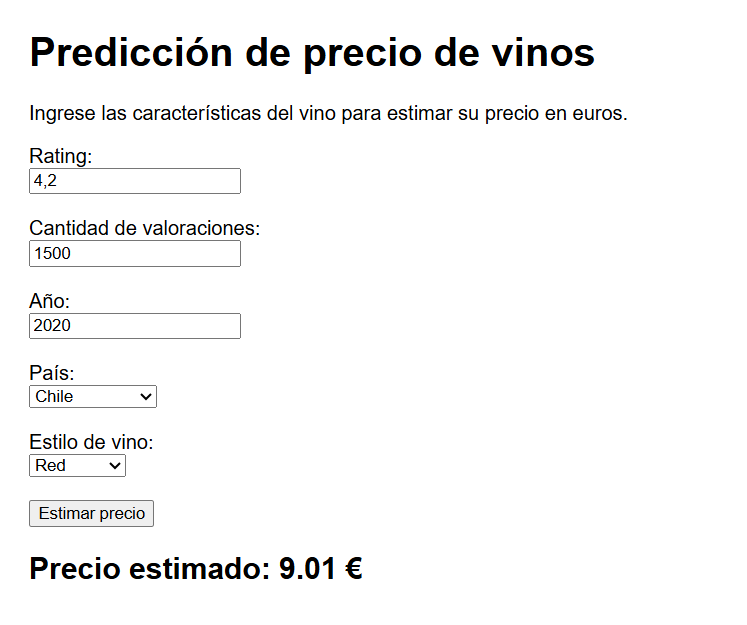

# **10. Set de datos de prueba**

En esta etapa se construye un set de datos de prueba a partir de la división realizada durante el entrenamiento del modelo. Este conjunto corresponde a los registros que no fueron utilizados para entrenar el modelo, por lo que permite evaluar su capacidad de generalización frente a datos no vistos.

En este proyecto, el modelo seleccionado fue Random Forest Regressor, ya que obtuvo el mejor desempeño en comparación con Regresión Lineal y Árbol de Decisión. Por este motivo, el set de prueba se construye utilizando `X_test` y `y_test`, generados durante la división del dataset, y se incorporan las predicciones del modelo final para comparar el precio real con el precio estimado.

In [ ]:
# Revisamos la cantidad de registros utilizados para entrenamiento y prueba
print("Cantidad de registros en X_train:", X_train.shape[0])
print("Cantidad de registros en X_test:", X_test.shape[0])

# Calculamos porcentaje de entrenamiento y prueba
total_registros = X_train.shape[0] + X_test.shape[0]

porcentaje_train = round((X_train.shape[0] / total_registros) * 100, 2)
porcentaje_test = round((X_test.shape[0] / total_registros) * 100, 2)

print("Porcentaje de entrenamiento:", porcentaje_train, "%")
print("Porcentaje de prueba:", porcentaje_test, "%")

Cantidad de registros en X_train: 9683
Cantidad de registros en X_test: 4151
Porcentaje de entrenamiento: 69.99 %
Porcentaje de prueba: 30.01 %


* Se validó la cantidad de registros utilizados en el conjunto de entrenamiento y en el conjunto de prueba. Esta separación permite confirmar qué proporción del dataset fue utilizada para entrenar el modelo y qué proporción fue reservada para evaluar su desempeño con datos no vistos.

* El resultado muestra la división del dataset en datos de entrenamiento y datos de prueba. Se utilizaron 9.683 registros para entrenar el modelo y 4.151 registros para evaluarlo. Esto corresponde aproximadamente a un 70% de los datos para entrenamiento y un 30% para prueba. Esta división permite que el modelo aprenda con una parte de los datos y luego sea evaluado con registros que no vio durante el entrenamiento.

In [ ]:
# Creamos una copia del set de prueba utilizado por el modelo
set_datos_prueba = X_test.copy()

# Convertimos y_test desde escala logarítmica a escala original
precio_real_prueba = np.expm1(y_test)

# Agregamos el precio real al set de prueba
set_datos_prueba["Precio_real_EUR"] = precio_real_prueba.values

# Visualizamos una muestra del set de prueba
set_datos_prueba.head(10)

,Rating,NumberOfRatings,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,Country_Chile,...,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white,Precio_real_EUR
1206,3.7,143,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,25.02
6016,4.2,507,2018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,25.12
3867,3.7,308,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,11.19
11382,4.1,159,2017,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,27.50
3603,3.3,29,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,8.40
379,4.0,1106,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,39.90
11757,3.9,238,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,7.36
7679,3.9,76,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,57.72
9818,3.3,49,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.99
5638,4.4,463,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,131.60


* Se construyó el set de datos de prueba utilizando `X_test`, que contiene las variables independientes reservadas para evaluación. Además, se incorporó el precio real del vino en euros, transformando `y_test` desde escala logarítmica a escala original mediante `expm1`.

* El resultado muestra una muestra del set de datos de prueba utilizado por el modelo. Se observan variables como Rating, NumberOfRatings, Year y columnas codificadas por país mediante One-Hot Encoding. Además, se agregó la columna Precio_real_EUR, que corresponde al precio real del vino en euros. Esta tabla permite revisar los datos que serán comparados posteriormente con las predicciones generadas por el modelo.

In [ ]:
# Definimos el modelo final
try:
    modelo_final
except NameError:
    modelo_final = rf

# Realizamos predicciones sobre el set de prueba en escala logarítmica
predicciones_prueba_log = modelo_final.predict(X_test)

# Convertimos las predicciones a escala original en euros
predicciones_prueba = np.expm1(predicciones_prueba_log)

# Evitamos posibles valores negativos
predicciones_prueba = np.maximum(predicciones_prueba, 0)

# Agregamos el precio estimado al set de prueba
set_datos_prueba["Precio_estimado_EUR"] = predicciones_prueba

# Calculamos la diferencia absoluta entre precio real y precio estimado
set_datos_prueba["Diferencia_EUR"] = abs(
    set_datos_prueba["Precio_real_EUR"] - set_datos_prueba["Precio_estimado_EUR"]
)

# Visualizamos los resultados principales
set_datos_prueba[[
    "Precio_real_EUR",
    "Precio_estimado_EUR",
    "Diferencia_EUR"
]].head(10)

,Precio_real_EUR,Precio_estimado_EUR,Diferencia_EUR
1206,25.02,10.675939,14.344061
6016,25.12,12.921368,12.198632
3867,11.19,7.560024,3.629976
11382,27.50,29.220178,1.720178
3603,8.40,9.478488,1.078488
379,39.90,45.484094,5.584094
11757,7.36,16.232060,8.872060
7679,57.72,35.164924,22.555076
9818,9.99,8.825704,1.164296
5638,131.60,51.973509,79.626491


* Se aplicó el modelo Random Forest Regressor sobre el set de prueba. Las predicciones fueron generadas en escala logarítmica y luego transformadas a euros mediante `expm1`. Finalmente, se calculó la diferencia entre el precio real y el precio estimado para analizar el comportamiento del modelo sobre datos no utilizados durante el entrenamiento.

* El resultado muestra la comparación entre el precio real del vino y el precio estimado por el modelo. También se calcula la diferencia absoluta entre ambos valores. Por ejemplo, en algunos casos la diferencia es baja, como 1,07 o 1,72 euros, lo que indica una predicción cercana al valor real. Sin embargo, en otros casos la diferencia es mayor, como 14,34 o 22,55 euros, lo que demuestra que el modelo puede presentar errores más altos en ciertos registros.

In [ ]:
# Calculamos métricas específicas de evaluación sobre el set de prueba
mae_prueba = mean_absolute_error(
    set_datos_prueba["Precio_real_EUR"],
    set_datos_prueba["Precio_estimado_EUR"]
)

mse_prueba = mean_squared_error(
    set_datos_prueba["Precio_real_EUR"],
    set_datos_prueba["Precio_estimado_EUR"]
)

rmse_prueba = np.sqrt(mse_prueba)

r2_prueba = r2_score(
    set_datos_prueba["Precio_real_EUR"],
    set_datos_prueba["Precio_estimado_EUR"]
)

# Mostramos resultados
print("MAE set de prueba:", mae_prueba)
print("MSE set de prueba:", mse_prueba)
print("RMSE set de prueba:", rmse_prueba)
print("R² set de prueba:", r2_prueba)

MAE set de prueba: 13.943249829113883
MSE set de prueba: 2411.1811373320566
RMSE set de prueba: 49.1037792571209
R² set de prueba: 0.5378640007776927


* Se calcularon métricas específicas sobre el set de prueba para evaluar el desempeño del modelo final. El MAE indica el error promedio en euros, el RMSE permite observar el impacto de errores grandes y el R² muestra qué proporción de la variabilidad del precio logra explicar el modelo.

* El resultado muestra las métricas utilizadas para evaluar el rendimiento del modelo sobre el set de prueba.

* El MAE fue de 13,94 euros, lo que indica que, en promedio, el modelo se equivoca aproximadamente en 13,94 euros por predicción.

* El RMSE fue de 49,10 euros, lo que evidencia que existen algunos errores grandes que elevan esta métrica.

* Finalmente, el R² fue de 0,5378, lo que significa que el modelo logra explicar aproximadamente el 53,78% de la variabilidad del precio de los vinos. En general, el modelo tiene un rendimiento aceptable, aunque presenta dificultades para estimar correctamente vinos con precios muy altos o valores atípicos.

#**11. Modelo k-means en todos los proyectos.**

El modelo Random Forest Regressor se utilizó como modelo principal para predecir el precio de los vinos. En cambio, K-Means se aplicó como modelo complementario de aprendizaje no supervisado, con el objetivo de segmentar los vinos en grupos con características similares, permitiendo identificar perfiles comerciales como vinos económicos, intermedios o premium.

Las variables seleccionadas son:

- Price: precio del vino.
- Rating: calificación promedio del vino.
- NumberOfRatings: cantidad de valoraciones recibidas.
- Year: año del vino.

In [ ]:
# Seleccionamos las variables numéricas que serán utilizadas para aplicar K-Means
# No se incluye Price, ya que el precio es la variable objetivo que se busca predecir en el proyecto
variables_kmeans = df_final[["Rating", "NumberOfRatings", "Year"]].copy()

# Eliminamos posibles valores nulos para evitar errores al entrenar el modelo
variables_kmeans = variables_kmeans.dropna()

# Guardamos el precio correspondiente a los mismos registros para analizarlo posteriormente por cluster
precios_kmeans = df_final.loc[variables_kmeans.index, "Price"]

# Visualizamos las primeras filas de las variables seleccionadas
variables_kmeans.head()

,Rating,NumberOfRatings,Year
0,4.2,100,2011
1,4.3,100,2017
2,3.9,100,2015
3,3.5,100,2019
4,3.9,100,2016


* Se seleccionaron las variables Rating, NumberOfRatings y Year para aplicar el modelo K-Means. No se utilizó Price como variable de entrada, ya que el precio corresponde a la variable objetivo del proyecto. Posteriormente, el precio se utilizará solo para interpretar los clusters obtenidos.

* Se muestran las primeras filas de las variables seleccionadas para aplicar K-Means: Rating, NumberOfRatings y Year. Se observa que cada vino tiene una calificación, una cantidad de valoraciones y un año asociado. Estas variables serán usadas por el algoritmo para encontrar similitudes entre los vinos y formar grupos.

In [ ]:
# Importamos StandardScaler para estandarizar las variables numéricas
from sklearn.preprocessing import StandardScaler

# Creamos el objeto escalador
scaler_kmeans = StandardScaler()

# Aplicamos el escalamiento a las variables seleccionadas
variables_kmeans_escaladas = scaler_kmeans.fit_transform(variables_kmeans)

# Visualizamos las primeras filas de los datos escalados
variables_kmeans_escaladas[:5]

array([[ 1.1279266 , -0.17859653, -1.42906554],
       [ 1.4652901 , -0.17859653,  0.4525378 ],
       [ 0.1158361 , -0.17859653, -0.17466331],
       [-1.2336179 , -0.17859653,  1.07973891],
       [ 0.1158361 , -0.17859653,  0.13893724]])

* Se aplicó StandardScaler para estandarizar las variables utilizadas en K-Means. Este paso es necesario porque el algoritmo calcula distancias entre registros, por lo que todas las variables deben estar en una escala comparable.

* El resultado muestra los primeros registros después de aplicar el escalamiento de variables. Los valores originales fueron transformados a una escala estandarizada, donde las variables quedan comparables entre sí. Esto es importante porque K-Means calcula distancias entre los datos, y si no se escalan las variables, una columna con valores más grandes, como NumberOfRatings, podría influir demasiado en la formación de los clusters.

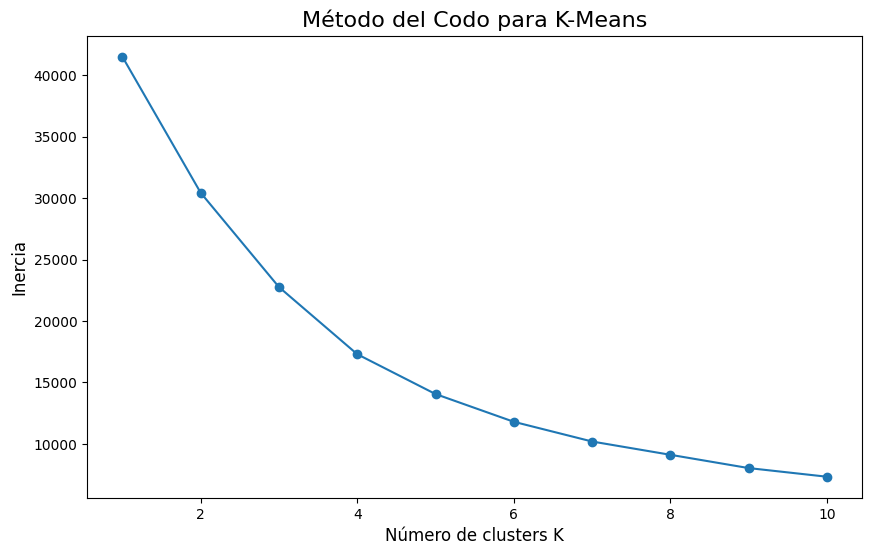

In [ ]:
# Importamos KMeans para aplicar el modelo de clustering
from sklearn.cluster import KMeans

# Importamos matplotlib para graficar los resultados
import matplotlib.pyplot as plt

# Creamos una lista vacía para guardar los valores de inercia
inercias = []

# Definimos el rango de clusters que se probarán
valores_k = range(1, 11)

# Probamos distintos valores de K entre 1 y 10
for k in valores_k:

    # Creamos el modelo K-Means con k clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=100,
        n_init=10
    )

    # Entrenamos el modelo con los datos escalados
    kmeans.fit(variables_kmeans_escaladas)

    # Guardamos la inercia obtenida para cada valor de K
    inercias.append(kmeans.inertia_)

# Creamos el gráfico del método del codo
plt.figure(figsize=(10, 6))
plt.plot(valores_k, inercias, marker="o")
plt.title("Método del Codo para K-Means", fontsize=16)
plt.xlabel("Número de clusters K", fontsize=12)
plt.ylabel("Inercia", fontsize=12)
plt.show()

* Se aplicó el método del codo para analizar distintos valores de K. Este método permite observar en qué punto la disminución de la inercia comienza a ser menos significativa, ayudando a seleccionar una cantidad adecuada de clusters.

* El gráfico del método del codo muestra cómo disminuye la inercia a medida que aumenta la cantidad de clusters. Se observa una caída fuerte entre K=1 y K=4, y luego la reducción comienza a ser más lenta. Esto indica que usar 4 clusters puede ser una opción razonable, ya que permite segmentar los vinos sin aumentar innecesariamente la cantidad de grupos.

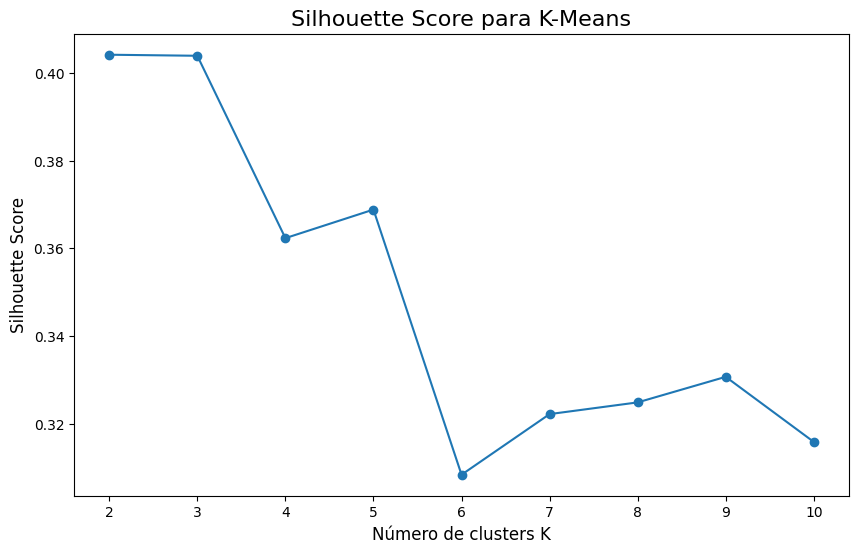

In [ ]:
# Importamos silhouette_score para evaluar la calidad de los clusters
from sklearn.metrics import silhouette_score

# Creamos una lista vacía para guardar los resultados de Silhouette Score
silhouette_scores = []

# Probamos valores de K desde 2 hasta 10
for k in range(2, 11):

    # Creamos el modelo K-Means con k clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=100,
        n_init=10
    )

    # Entrenamos el modelo y asignamos cada registro a un cluster
    labels = kmeans.fit_predict(variables_kmeans_escaladas)

    # Calculamos el Silhouette Score para evaluar la separación de los clusters
    score = silhouette_score(variables_kmeans_escaladas, labels)

    # Guardamos el resultado obtenido
    silhouette_scores.append(score)

# Graficamos los resultados de Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker="o")
plt.title("Silhouette Score para K-Means", fontsize=16)
plt.xlabel("Número de clusters K", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.show()

* Se utilizó Silhouette Score como métrica complementaria para evaluar la calidad de los clusters. Esta métrica permite analizar qué tan bien separados se encuentran los grupos generados por K-Means. Un valor más alto indica una mejor separación entre clusters.

* El gráfico de Silhouette Score muestra la calidad de separación entre los clusters para distintos valores de K. Los mejores resultados se observan en K=2 y K=3, ya que presentan los valores más altos. Sin embargo, se puede mantener K=4 porque permite obtener una segmentación más detallada de los vinos, aunque con una separación levemente menor entre los grupos.

In [ ]:
# Creamos el modelo K-Means final con 4 clusters
kmeans_final = KMeans(
    n_clusters=4,
    random_state=100,
    n_init=10
)

# Entrenamos el modelo y asignamos cada vino a un cluster
clusters = kmeans_final.fit_predict(variables_kmeans_escaladas)

# Creamos un dataframe con las variables utilizadas en el modelo
df_kmeans_resultado = variables_kmeans.copy()

# Agregamos el precio real para analizar el comportamiento de precio en cada cluster
df_kmeans_resultado["Price"] = precios_kmeans

# Agregamos el cluster asignado a cada vino
df_kmeans_resultado["Cluster"] = clusters

# Visualizamos las primeras filas con el cluster asignado
df_kmeans_resultado.head()

,Rating,NumberOfRatings,Year,Price,Cluster
0,4.2,100,2011,95.00,3
1,4.3,100,2017,15.50,0
2,3.9,100,2015,7.45,0
3,3.5,100,2019,8.72,1
4,3.9,100,2016,29.15,0


* Se entrenó el modelo K-Means con 4 clusters, asignando cada vino a un grupo según sus características de rating, cantidad de valoraciones y año. Luego, se agregó el precio real para interpretar el comportamiento comercial de cada segmento.

* El resultado muestra que a cada vino se le asignó un número de cluster. Por ejemplo, algunos vinos fueron asignados al cluster 0, otros al cluster 1 y otros al cluster 3. Esta asignación se realiza según la similitud entre los vinos considerando Rating, NumberOfRatings y Year.

In [ ]:
# Contamos la cantidad de vinos asignados a cada cluster
cantidad_por_cluster = df_kmeans_resultado["Cluster"].value_counts().sort_index()

# Mostramos la cantidad de registros por cluster
cantidad_por_cluster

,count
Cluster,
0,5991
1,6756
2,6
3,1081


* Se contabilizó la cantidad de vinos pertenecientes a cada cluster. Esto permite verificar si los grupos están equilibrados o si existe concentración de registros en algún segmento específico.

* El resultado muestra cuántos vinos quedaron asignados a cada cluster. El cluster 1 concentra la mayor cantidad de registros, con 6.756 vinos, seguido por el cluster 0 con 5.991 vinos. El cluster 3 tiene 1.081 vinos, mientras que el cluster 2 solo contiene 6 registros. Esto indica que los clusters 0 y 1 representan los segmentos más comunes del dataset, mientras que el cluster 2 corresponde a un grupo muy pequeño y posiblemente atípico.

In [ ]:
# Calculamos estadísticas promedio, mínimas, máximas y cantidad de registros por cluster
analisis_clusters = df_kmeans_resultado.groupby("Cluster").agg({
    "Rating": "mean",
    "NumberOfRatings": "mean",
    "Year": "mean",
    "Price": ["mean", "min", "max", "count"]
})

# Mostramos el análisis de clusters
analisis_clusters

Rating NumberOfRatings         Year       Price                 \
             mean            mean         mean        mean   min      max   
Cluster                                                                     
0        4.080905      475.595727  2015.743115   41.599341  3.15  1115.50   
1        3.629085      321.040853  2016.700562   12.705078  3.15   115.00   
2        4.166667    66318.666667  2016.000000   56.840000  4.35   170.00   
3        4.149676      471.096207  2007.375578  112.365939  6.30  3410.79   

               
        count  
Cluster        
0        5991  
1        6756  
2           6  
3        1081

* El análisis de clusters permite interpretar las características promedio de cada grupo. Aunque el precio no fue utilizado para entrenar el modelo K-Means, se incorporó posteriormente para analizar qué segmentos presentan precios más bajos, intermedios o altos.

* El resultado permite interpretar qué representa cada cluster. El cluster 0 tiene un rating promedio de 4,08, aproximadamente 476 valoraciones promedio y un precio promedio de 41,60 euros, por lo que puede representar vinos de valoración media-alta y precio intermedio. El cluster 1 tiene el rating promedio más bajo, 3,63, y el precio promedio más bajo, 12,71 euros, por lo que representa vinos más económicos y de menor valoración. El cluster 2 tiene solo 6 vinos, pero destaca por una cantidad extremadamente alta de valoraciones promedio, sobre 66.000, por lo que puede considerarse un grupo atípico de vinos muy populares. Finalmente, el cluster 3 tiene el precio promedio más alto, 112,37 euros, y un año promedio más antiguo, 2007, por lo que representa vinos de mayor valor comercial o perfil premium.

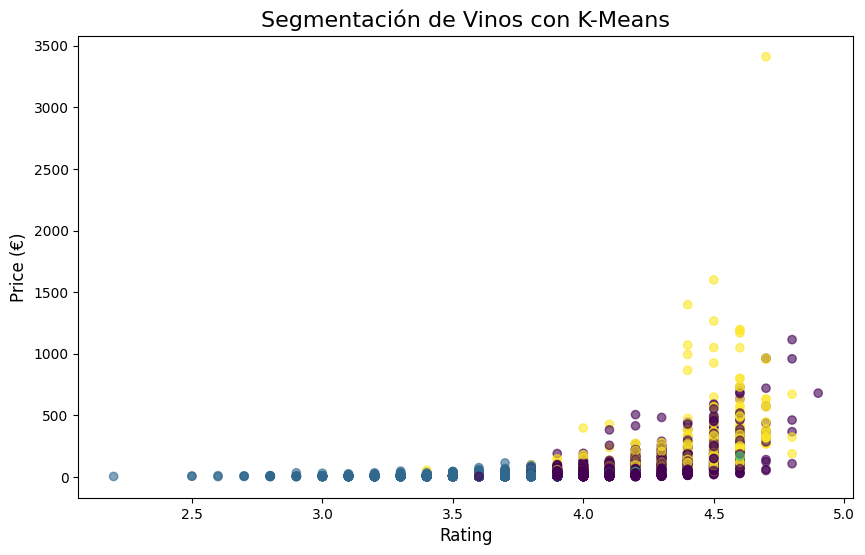

In [ ]:
# Creamos un gráfico de dispersión para visualizar los clusters
plt.figure(figsize=(10, 6))

# Graficamos Rating en el eje X y Price en el eje Y, coloreando según el cluster asignado
plt.scatter(
    df_kmeans_resultado["Rating"],
    df_kmeans_resultado["Price"],
    c=df_kmeans_resultado["Cluster"],
    alpha=0.6
)

# Agregamos título y etiquetas al gráfico
plt.title("Segmentación de Vinos con K-Means", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Price (€)", fontsize=12)

# Mostramos el gráfico
plt.show()

* El gráfico permite visualizar la distribución de los clusters considerando el rating y el precio de los vinos. Aunque el precio no fue utilizado como entrada del modelo, su visualización permite interpretar cómo se comporta cada segmento en términos comerciales.

* El gráfico muestra la distribución de los vinos según Rating y Price, coloreados de acuerdo con el cluster asignado. Se observa que la mayoría de los vinos se concentra en precios bajos o medios, mientras que existen algunos registros con precios muy altos que se alejan del resto. También se aprecia que los vinos con rating más alto tienden a presentar precios más elevados, especialmente en los casos atípicos. Esta visualización ayuda a entender cómo los clusters se distribuyen en relación con el precio, aunque el precio no haya sido usado para entrenar K-Means.

In [ ]:
# Creamos una tabla resumen con los promedios principales por cluster
resumen_clusters = df_kmeans_resultado.groupby("Cluster").agg({
    "Rating": "mean",
    "NumberOfRatings": "mean",
    "Year": "mean",
    "Price": "mean"
}).round(2)

# Renombramos las columnas para facilitar la lectura
resumen_clusters = resumen_clusters.rename(columns={
    "Rating": "Rating_promedio",
    "NumberOfRatings": "Valoraciones_promedio",
    "Year": "Año_promedio",
    "Price": "Precio_promedio_EUR"
})

# Mostramos el resumen final
resumen_clusters

,Rating_promedio,Valoraciones_promedio,Año_promedio,Precio_promedio_EUR
Cluster,,,,
0,4.08,475.60,2015.74,41.60
1,3.63,321.04,2016.70,12.71
2,4.17,66318.67,2016.00,56.84
3,4.15,471.10,2007.38,112.37


* Se generó una tabla resumen para facilitar la interpretación de los clusters. Esta tabla permite comparar el rating promedio, la cantidad promedio de valoraciones, el año promedio y el precio promedio de los vinos pertenecientes a cada segmento.

* El resumen final facilita la comparación entre los clusters. El cluster 0 agrupa vinos con buen rating promedio, 4,08, cantidad moderada de valoraciones y precio promedio de 41,60 euros. El cluster 1 representa vinos más económicos, con menor rating promedio y precio promedio de 12,71 euros. El cluster 2 corresponde a un grupo pequeño de vinos muy populares, con un promedio de 66.318 valoraciones, pero solo 6 registros. El cluster 3 agrupa vinos más antiguos, con buen rating y el precio promedio más alto, alcanzando 112,37 euros. En conjunto, estos resultados permiten identificar distintos perfiles comerciales de vinos dentro del dataset.

K-Means es un modelo no supervisado, por lo que no se le asigna previamente el significado de cada grupo. El algoritmo primero agrupa los vinos según similitudes en Rating, NumberOfRatings y Year. Luego, a partir del análisis de las características promedio de cada cluster, se interpreta el significado comercial de cada segmento.

**Cluster 0:** vinos con rating más bajo y pocas valoraciones.

**Cluster 1:** vinos de valoración media.

**Cluster 2:** vinos muy populares o atípicos.

**Cluster 3:** vinos con mejor rating y mayor reconocimiento.

# **12. Métricas específicas de evaluación de rendimiento (regresión)**

En esta etapa se calculan métricas específicas para evaluar el rendimiento de los modelos de regresión utilizados en el proyecto. Como el objetivo principal es predecir el precio de los vinos, el problema corresponde a regresión, ya que la variable objetivo es numérica.

Las métricas utilizadas son:

- **MAE:** mide el error absoluto promedio entre el precio real y el precio estimado.
- **MSE:** mide el error cuadrático promedio, penalizando más los errores grandes.
- **RMSE:** representa la raíz del error cuadrático medio, expresada en la misma unidad del precio.
- **R²:** mide qué proporción de la variabilidad del precio logra explicar el modelo.

Estas métricas permiten comparar el desempeño de los modelos evaluados y justificar la selección del modelo final.

In [ ]:
# Importamos las métricas necesarias para evaluar modelos de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
# Convertimos y_test desde escala logarítmica a escala original
y_test_original = np.expm1(y_test)

# Validamos los primeros valores reales en euros
y_test_original[:10]

,Price
1206,25.02
6016,25.12
3867,11.19
11382,27.50
3603,8.40
379,39.90
11757,7.36
7679,57.72
9818,9.99
5638,131.60


* Se transformó la variable objetivo del set de prueba desde escala logarítmica a escala original utilizando `expm1`. Esto permite interpretar los resultados en euros, que es la unidad original del precio del vino.

* El resultado muestra los primeros valores reales del precio de los vinos en euros, luego de convertir la variable y_test desde escala logarítmica a su escala original mediante np.expm1(). Esto permite trabajar nuevamente con precios interpretables, como 25,02 €, 11,19 €, 57,72 € o 131,60 €, en lugar de valores transformados logarítmicamente.

In [ ]:
# Diccionario con los modelos evaluados
modelos_evaluados = {
    "Regresión Lineal": lr,
    "Árbol de Decisión": tree,
    "Random Forest": rf
}

# Lista para almacenar los resultados de evaluación
resultados_metricas = []

# Recorremos cada modelo para calcular sus métricas
for nombre_modelo, modelo in modelos_evaluados.items():

    # Realizamos predicciones en escala logarítmica
    y_pred_log = modelo.predict(X_test)

    # Convertimos las predicciones a escala original
    y_pred_original = np.expm1(y_pred_log)

    # Evitamos posibles valores negativos
    y_pred_original = np.maximum(y_pred_original, 0)

    # Calculamos métricas de regresión
    mae = mean_absolute_error(y_test_original, y_pred_original)
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_original, y_pred_original)

    # Guardamos los resultados
    resultados_metricas.append({
        "Modelo": nombre_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

# Creamos DataFrame con los resultados
df_metricas = pd.DataFrame(resultados_metricas)

# Ordenamos por menor RMSE
df_metricas = df_metricas.sort_values(by="RMSE", ascending=True)

df_metricas

,Modelo,MAE,MSE,RMSE,R2
2,Random Forest,13.943250,2411.181137,49.103779,0.537864
0,Regresión Lineal,15.294588,3167.813473,56.283332,0.392845
1,Árbol de Decisión,16.396430,7067.367579,84.067637,-0.354558


* Se calcularon las métricas MAE, MSE, RMSE y R² para cada modelo evaluado. Las predicciones fueron transformadas desde escala logarítmica a escala original para que los errores sean interpretables en euros. Posteriormente, los modelos fueron ordenados según RMSE, ya que esta métrica permite identificar el modelo con menor error promedio penalizando diferencias grandes.

* El resultado muestra la comparación de rendimiento entre los modelos evaluados: Random Forest, Regresión Lineal y Árbol de Decisión. Según las métricas obtenidas, Random Forest presenta el mejor desempeño, ya que tiene el menor MAE, MSE y RMSE, además del mayor R². Esto indica que es el modelo que logra estimar los precios con menor error en comparación con los otros modelos.

In [ ]:
# Seleccionamos el modelo con menor RMSE
mejor_modelo_metricas = df_metricas.iloc[0]

print("Mejor modelo según RMSE:", mejor_modelo_metricas["Modelo"])
print("MAE:", round(mejor_modelo_metricas["MAE"], 2))
print("MSE:", round(mejor_modelo_metricas["MSE"], 2))
print("RMSE:", round(mejor_modelo_metricas["RMSE"], 2))
print("R²:", round(mejor_modelo_metricas["R2"], 4))

Mejor modelo según RMSE: Random Forest
MAE: 13.94
MSE: 2411.18
RMSE: 49.1
R²: 0.5379


Las métricas utilizadas son:

- **MAE:** mide el error absoluto promedio entre el precio real y el precio estimado.
- **MSE:** mide el error cuadrático promedio, penalizando más los errores grandes.
- **RMSE:** representa la raíz del error cuadrático medio, expresada en la misma unidad del precio.
- **R²:** mide qué proporción de la variabilidad del precio logra explicar el modelo.

* Se seleccionó el mejor modelo según el menor RMSE, ya que esta métrica permite identificar el modelo con menor error general en la predicción del precio. Además, se revisó el valor de R² para evaluar qué tan bien el modelo logra explicar la variabilidad del precio de los vinos.

* El resultado confirma que el mejor modelo según la métrica RMSE es Random Forest. Este modelo obtuvo un MAE de 13,94, un MSE de 2411,18, un RMSE de 49,10 y un R² de 0,5379. Esto significa que, en promedio, el modelo presenta un error absoluto cercano a 13,94 euros, y logra explicar aproximadamente el 53,79% de la variabilidad del precio de los vinos.

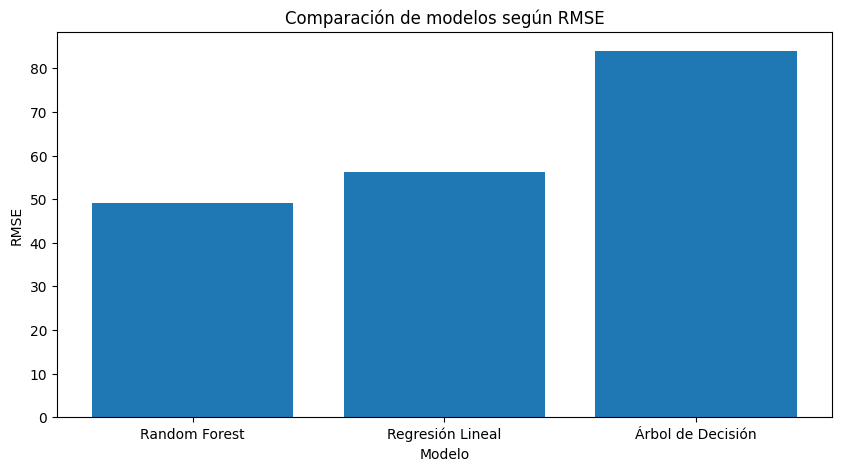

In [ ]:
# Importamos librería para visualización
import matplotlib.pyplot as plt

# Configuramos tamaño del gráfico
plt.figure(figsize=(10,5))

# Graficamos RMSE por modelo
plt.bar(df_metricas["Modelo"], df_metricas["RMSE"])

# Título y etiquetas
plt.title("Comparación de modelos según RMSE")
plt.ylabel("RMSE")
plt.xlabel("Modelo")

# Mostramos gráfico
plt.show()

* Se generó un gráfico comparativo del RMSE por modelo. Esta visualización permite observar de forma clara cuál modelo presenta menor error en la estimación del precio de los vinos.

* El gráfico compara visualmente el RMSE de los tres modelos evaluados. Se observa que Random Forest presenta el RMSE más bajo, seguido por Regresión Lineal, mientras que Árbol de Decisión obtiene el error más alto. Como en RMSE un valor menor representa un mejor desempeño, este resultado refuerza que Random Forest es el modelo más adecuado para la predicción del precio de los vinos.

In [ ]:
# Definimos el modelo final si aún no existe
try:
    modelo_final
except NameError:
    modelo_final = rf

# Predicción del modelo final sobre el set de prueba
prediccion_final_log = modelo_final.predict(X_test)

# Conversión a escala original
prediccion_final_eur = np.expm1(prediccion_final_log)

# Evitamos valores negativos
prediccion_final_eur = np.maximum(prediccion_final_eur, 0)

# Creamos tabla comparativa
comparacion_final = pd.DataFrame({
    "Precio_real_EUR": y_test_original,
    "Precio_estimado_EUR": prediccion_final_eur,
    "Diferencia_EUR": abs(y_test_original - prediccion_final_eur)
})

# Visualizamos una muestra
comparacion_final.head(10)

,Precio_real_EUR,Precio_estimado_EUR,Diferencia_EUR
1206,25.02,10.675939,14.344061
6016,25.12,12.921368,12.198632
3867,11.19,7.560024,3.629976
11382,27.50,29.220178,1.720178
3603,8.40,9.478488,1.078488
379,39.90,45.484094,5.584094
11757,7.36,16.232060,8.872060
7679,57.72,35.164924,22.555076
9818,9.99,8.825704,1.164296
5638,131.60,51.973509,79.626491


* Se generó una tabla comparativa entre el precio real y el precio estimado por el modelo final. Esta comparación permite observar de forma directa el nivel de diferencia entre las predicciones y los valores reales del set de prueba.

* El resultado muestra una comparación entre el precio real del vino, el precio estimado por el modelo y la diferencia absoluta entre ambos valores. En algunos registros, el modelo logra predicciones cercanas al valor real, como diferencias de 1,07 €, 1,16 € o 1,72 €. Sin embargo, también existen casos con diferencias más altas, como 22,55 € o 79,63 €, lo que indica que el modelo tiene mayor dificultad para estimar correctamente vinos de precio elevado o registros atípicos.

# **13. Conclusiones**

En conclusión, el desarrollo de este proyecto permitió aplicar un proceso completo de análisis de datos y modelamiento predictivo orientado a la estimación del precio de vinos. A partir del dataset utilizado, se realizó la preparación de los datos, selección de variables, transformación de la variable objetivo y entrenamiento de distintos modelos de regresión, con el propósito de comparar su rendimiento y seleccionar el más adecuado.

Dentro de los modelos evaluados, Random Forest Regressor obtuvo el mejor desempeño en comparación con Regresión Lineal y Árbol de Decisión, alcanzando un MAE de 13,94, un RMSE de 49,10 y un R² de 0,5379. Estos resultados indican que el modelo logra realizar estimaciones razonables del precio de los vinos, aunque presenta mayores dificultades en registros con precios elevados o valores atípicos.

Además, se incorporó el modelo K-Means como complemento al análisis predictivo. Si bien K-Means no permite predecir directamente el precio, sí permitió segmentar los vinos en grupos con características similares según rating, cantidad de valoraciones y año. Esta segmentación facilitó la identificación de perfiles comerciales, como vinos económicos, vinos de precio intermedio, vinos populares y vinos de mayor valor comercial.

También se integraron datos reales obtenidos mediante técnicas de web scraping, lo que permitió probar el modelo con información externa y acercar el análisis a un contexto más realista. Asimismo, la visualización mediante dashboard permitió representar los principales indicadores de manera clara y apoyar la interpretación de los resultados obtenidos.

En términos generales, el proyecto demuestra que el uso de modelos de machine learning puede apoyar la estimación de precios y el análisis comercial de vinos. No obstante, el rendimiento del modelo podría mejorar incorporando nuevas variables relevantes, como cepa, viña, denominación de origen, premios, país, región o características específicas del producto. Aun así, el trabajo desarrollado cumple con el objetivo de construir, evaluar y complementar un modelo predictivo, aportando una base sólida para futuras mejoras.



---



